In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.makedirs("../reports/figures", exist_ok=True)
print("Figures directory ready!")

# Visual settings
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

# 1. Cleaned datasets load karna
orders = pd.read_csv("../data/processed/orders_cleaned.csv")
order_items = pd.read_csv("../data/processed/order_items_cleaned.csv")
products = pd.read_csv("../data/processed/products_cleaned.csv")
payments = pd.read_csv("../data/processed/order_payments_cleaned.csv")

# 2. Datetime columns parse karna
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])
orders["order_delivered_customer_date"] = pd.to_datetime(orders["order_delivered_customer_date"])

print("Datasets loaded successfully!")
print("Orders shape:", orders.shape)
print("Order items shape:", order_items.shape)
print("Date range:", orders["order_purchase_timestamp"].min(), "to", orders["order_purchase_timestamp"].max())

In [ ]:
# Monthly Sales & Orders Dual-Axis Plot
fig, ax1 = plt.subplots(figsize=(14, 6))

color1 = "tab:blue"
ax1.set_xlabel("Year-Month", fontsize=12)
ax1.set_ylabel("Total Revenue (R$)", color=color1, fontsize=12)
line1 = ax1.plot(monthly_metrics["year_month"], monthly_metrics["total_revenue"], color=color1, marker="o", linewidth=2.5, label="Revenue (R$)")
ax1.tick_params(axis="y", labelcolor=color1)
ax1.set_xticks(range(len(monthly_metrics["year_month"])))
ax1.set_xticklabels(monthly_metrics["year_month"], rotation=45, ha="right")

ax2 = ax1.twinx()
color2 = "tab:orange"
ax2.set_ylabel("Order Count", color=color2, fontsize=12)
line2 = ax2.plot(monthly_metrics["year_month"], monthly_metrics["total_orders"], color=color2, marker="s", linestyle="--", linewidth=2, label="Order Count")
ax2.tick_params(axis="y", labelcolor=color2)
ax2.grid(False)

# Legend merge
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left", frameon=True)

plt.title("Monthly Revenue & Order Volume Growth (Delivered Orders)", fontsize=14, weight="bold")
fig.tight_layout()

# Save image
plt.savefig("../reports/figures/01_monthly_revenue_orders_trend.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: reports/figures/01_monthly_revenue_orders_trend.png")

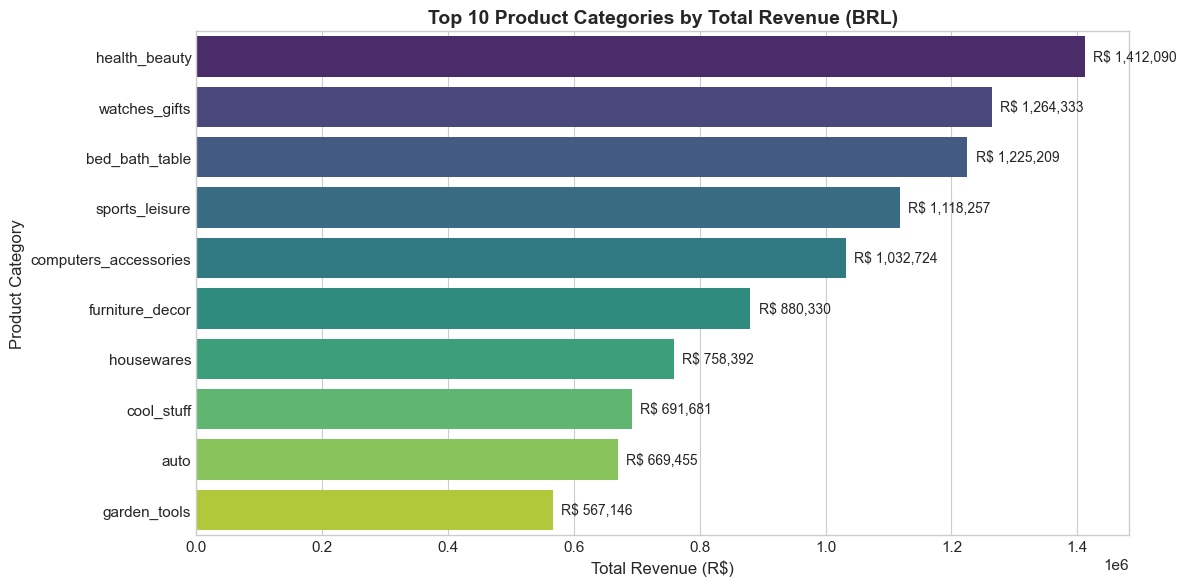

Chart saved successfully to ../reports/figures/02_top_10_categories_revenue.png


,product_category_name_english,total_revenue,total_items_sold
43,health_beauty,1412089.53,9465
73,watches_gifts,1264333.12,5859
7,bed_bath_table,1225209.26,10953
67,sports_leisure,1118256.91,8431
15,computers_accessories,1032723.77,7644
39,furniture_decor,880329.92,8160
49,housewares,758392.25,6795
20,cool_stuff,691680.89,3718
5,auto,669454.75,4140
42,garden_tools,567145.68,4268


In [15]:
#  2. Top 10 Product Categories by Revenue

# 1. Sales DataFrame ensure karna (with product identifiers)

sales_df = delivered_orders.merge(
    order_items[["order_id", "order_item_id", "product_id", "price", "freight_value"]],
    on="order_id",
    how="inner"
)
sales_df["total_value"] = sales_df["price"] + sales_df["freight_value"]

# 2. Products table ke sath merge karke English category names lena
category_sales = sales_df.merge(
    products[["product_id", "product_category_name_english"]],
    on="product_id",
    how="inner"
)

# 3. Category level summary aggregate karna
cat_summary = category_sales.groupby("product_category_name_english").agg(
    total_revenue=("total_value", "sum"),
    total_items_sold=("order_item_id", "count"),
    unique_orders=("order_id", "nunique")
).reset_index()

# 4. Top 10 categories sort karna
top10_revenue = cat_summary.sort_values(by="total_revenue", ascending=False).head(10)

# 5. Plotting (Object-Oriented Matplotlib)
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=top10_revenue,
    x="total_revenue",
    y="product_category_name_english",
    hue="product_category_name_english",
    palette="viridis",
    legend=False,
    ax=ax
)

ax.set_title("Top 10 Product Categories by Total Revenue (BRL)", fontsize=14, weight="bold")
ax.set_xlabel("Total Revenue (R$)", fontsize=12)
ax.set_ylabel("Product Category", fontsize=12)

# Value labels bar ke aage lagana
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f"R$ {width:,.0f}",
        (width, p.get_y() + p.get_height() / 2.),
        ha="left", va="center",
        xytext=(6, 0),
        textcoords="offset points",
        fontsize=10
    )

fig.tight_layout()

# 6. Save image to reports/figures
plt.savefig("../reports/figures/02_top_10_categories_revenue.png", dpi=300, bbox_inches="tight")
plt.show()

print("Chart saved successfully to ../reports/figures/02_top_10_categories_revenue.png")

# Display top 10 table
display(top10_revenue[["product_category_name_english", "total_revenue", "total_items_sold"]])

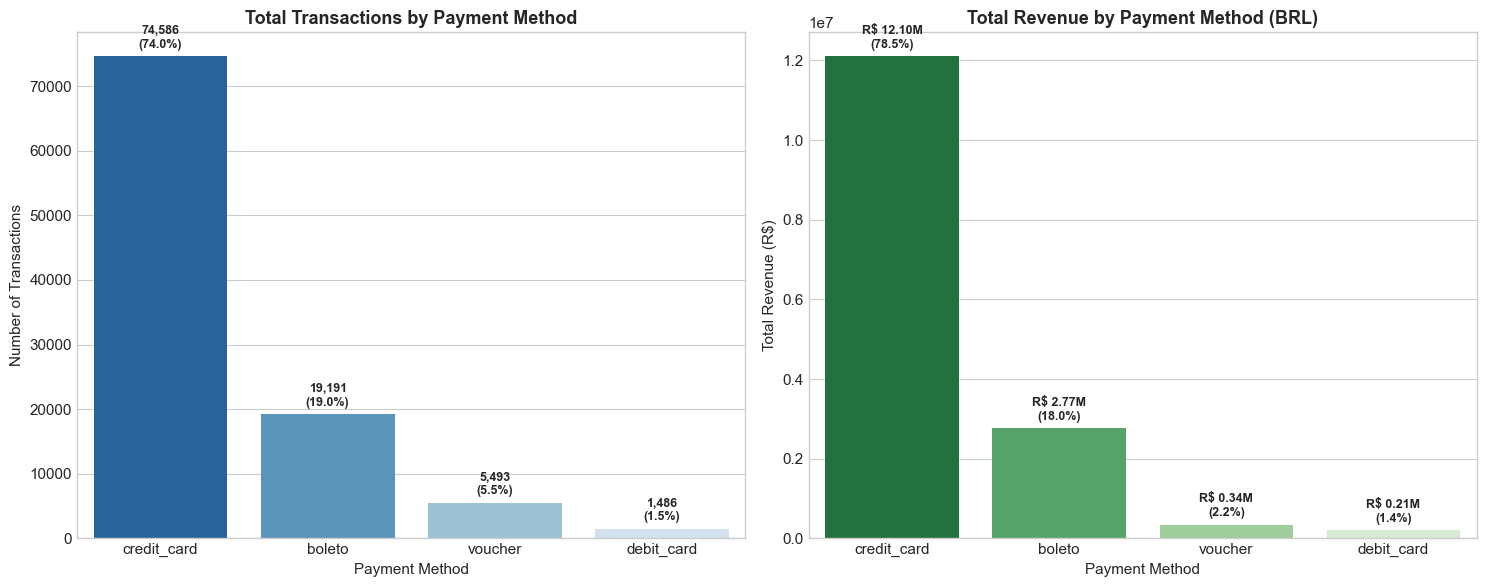

Chart saved successfully to ../reports/figures/03_payment_method_distribution.png


,payment_type,total_transactions,total_payment_value,avg_transaction_value,pct_transactions,pct_revenue
1,credit_card,74586,12101094.88,162.243516,74.026361,78.464094
0,boleto,19191,2769932.58,144.334979,19.047005,17.960379
3,voucher,5493,343013.19,62.445511,5.451785,2.224114
2,debit_card,1486,208421.12,140.256474,1.474850,1.351413


In [16]:
# ==============================================================
# Graph 3: Payment Methods Distribution (Volume vs Total Revenue)
# ==============================================================

# 1. Delivered orders ko payments table ke sath merge karna
order_payments_merged = delivered_orders.merge(payments, on="order_id", how="inner")

# 2. Payment Type Distribution summarize karna
pay_summary = order_payments_merged.groupby("payment_type").agg(
    total_transactions=("payment_sequential", "count"),
    total_payment_value=("payment_value", "sum"),
    avg_transaction_value=("payment_value", "mean")
).reset_index()

# Percentages calculate karna
pay_summary["pct_transactions"] = (pay_summary["total_transactions"] / pay_summary["total_transactions"].sum()) * 100
pay_summary["pct_revenue"] = (pay_summary["total_payment_value"] / pay_summary["total_payment_value"].sum()) * 100
pay_summary = pay_summary.sort_values(by="total_transactions", ascending=False)

# 3. Figure & Subplots Setup (1 Row, 2 Columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Subplot 1: Transaction Share
sns.barplot(
    data=pay_summary, 
    x="payment_type", 
    y="total_transactions", 
    hue="payment_type",
    palette="Blues_r",
    legend=False,
    ax=ax1
)
ax1.set_title("Total Transactions by Payment Method", fontsize=13, weight="bold")
ax1.set_xlabel("Payment Method", fontsize=11)
ax1.set_ylabel("Number of Transactions", fontsize=11)

# Annotations (Values & Percentages) for ax1
for p in ax1.patches:
    height = p.get_height()
    pct = (height / pay_summary["total_transactions"].sum()) * 100
    ax1.annotate(
        f"{int(height):,}\n({pct:.1f}%)",
        (p.get_x() + p.get_width() / 2., height),
        ha="center", va="bottom",
        xytext=(0, 4),
        textcoords="offset points",
        fontsize=9, weight="bold"
    )

# Subplot 2: Total Revenue Share
sns.barplot(
    data=pay_summary, 
    x="payment_type", 
    y="total_payment_value", 
    hue="payment_type",
    palette="Greens_r",
    legend=False,
    ax=ax2
)
ax2.set_title("Total Revenue by Payment Method (BRL)", fontsize=13, weight="bold")
ax2.set_xlabel("Payment Method", fontsize=11)
ax2.set_ylabel("Total Revenue (R$)", fontsize=11)

# Annotations (Revenue Values in Millions/Thousands) for ax2
for p in ax2.patches:
    height = p.get_height()
    pct = (height / pay_summary["total_payment_value"].sum()) * 100
    ax2.annotate(
        f"R$ {height/1e6:.2f}M\n({pct:.1f}%)",
        (p.get_x() + p.get_width() / 2., height),
        ha="center", va="bottom",
        xytext=(0, 4),
        textcoords="offset points",
        fontsize=9, weight="bold"
    )

fig.tight_layout()

# 4. Image Save
plt.savefig("../reports/figures/03_payment_method_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print("Chart saved successfully to ../reports/figures/03_payment_method_distribution.png")

# 5. Summary Table
display(pay_summary)